In [12]:
%matplotlib notebook
import Tafel_LPR_fit_notebook_IRcomp_IFilm as tf
import pandas as pd

# Example datasets (absolute current exported from other software)
These two files show how to use the repo when the exported current is **all positive** (absolute value):

- **One-step scan** (cathodic → anodic, two columns): `validate_one_step_scan.xlsx`
- **Two-step scan** (OCP → cathodic, then OCP → anodic, four columns): `validate_two_step_scan.xlsx`

For the one-step example we fit the standard Butler–Volmer equation.
For the two-step example we fit the Butler–Volmer + film model, which accounts for secondary film dissolution and growth current.


<IPython.core.display.Javascript object>


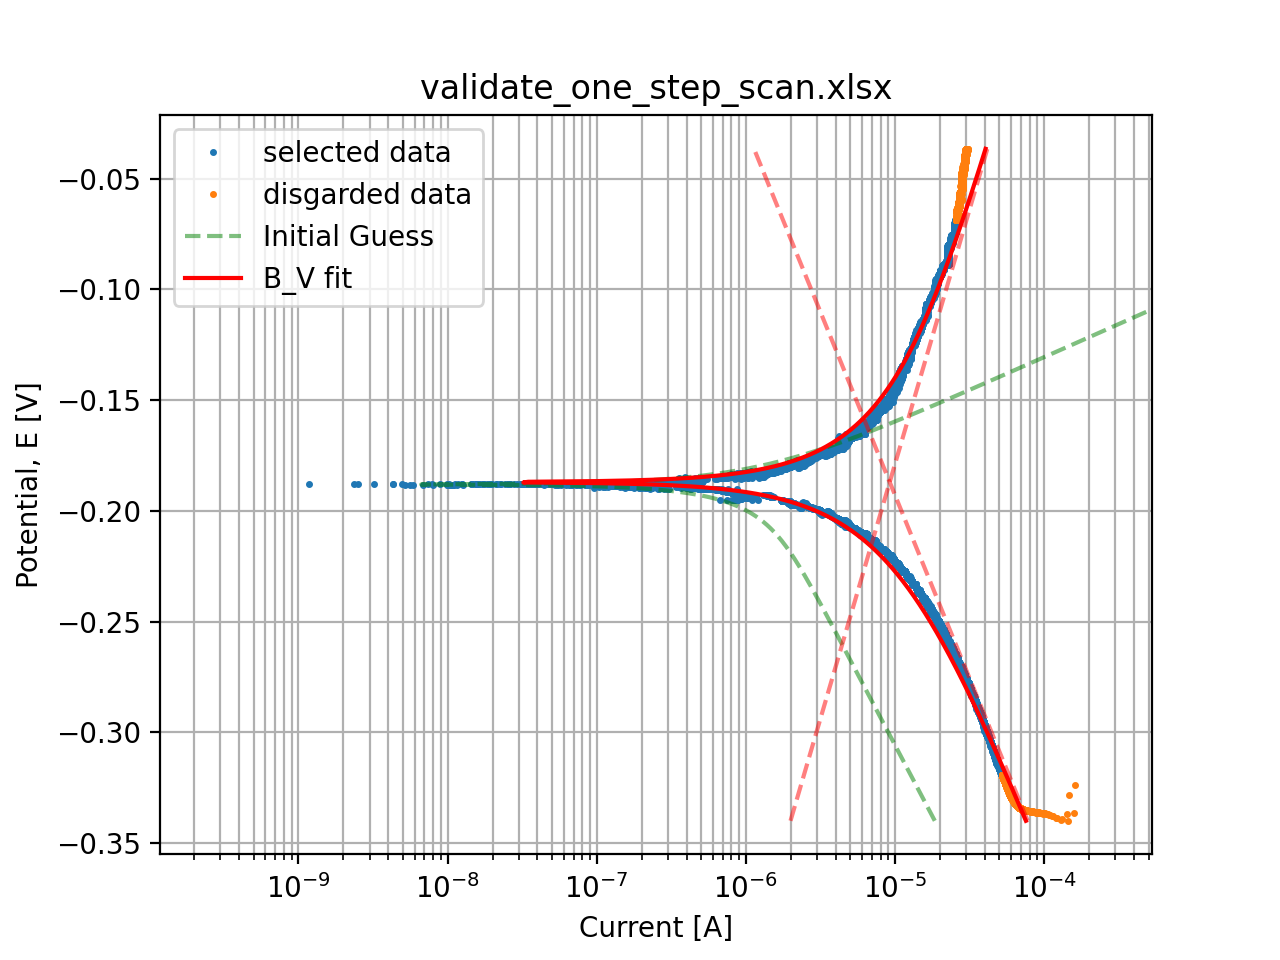

interactive(children=(IntRangeSlider(value=(9, 29847), continuous_update=False, description='data_range', layo…

In [2]:
# One-step scan with absolute (positive) current
test1 = tf.Tafit(tf.Info('validate_one_step_scan.xlsx',area=1.0))
test1.BV_LPR_interact(anodic_range=0.15,cathodic_range=0.15)


<IPython.core.display.Javascript object>


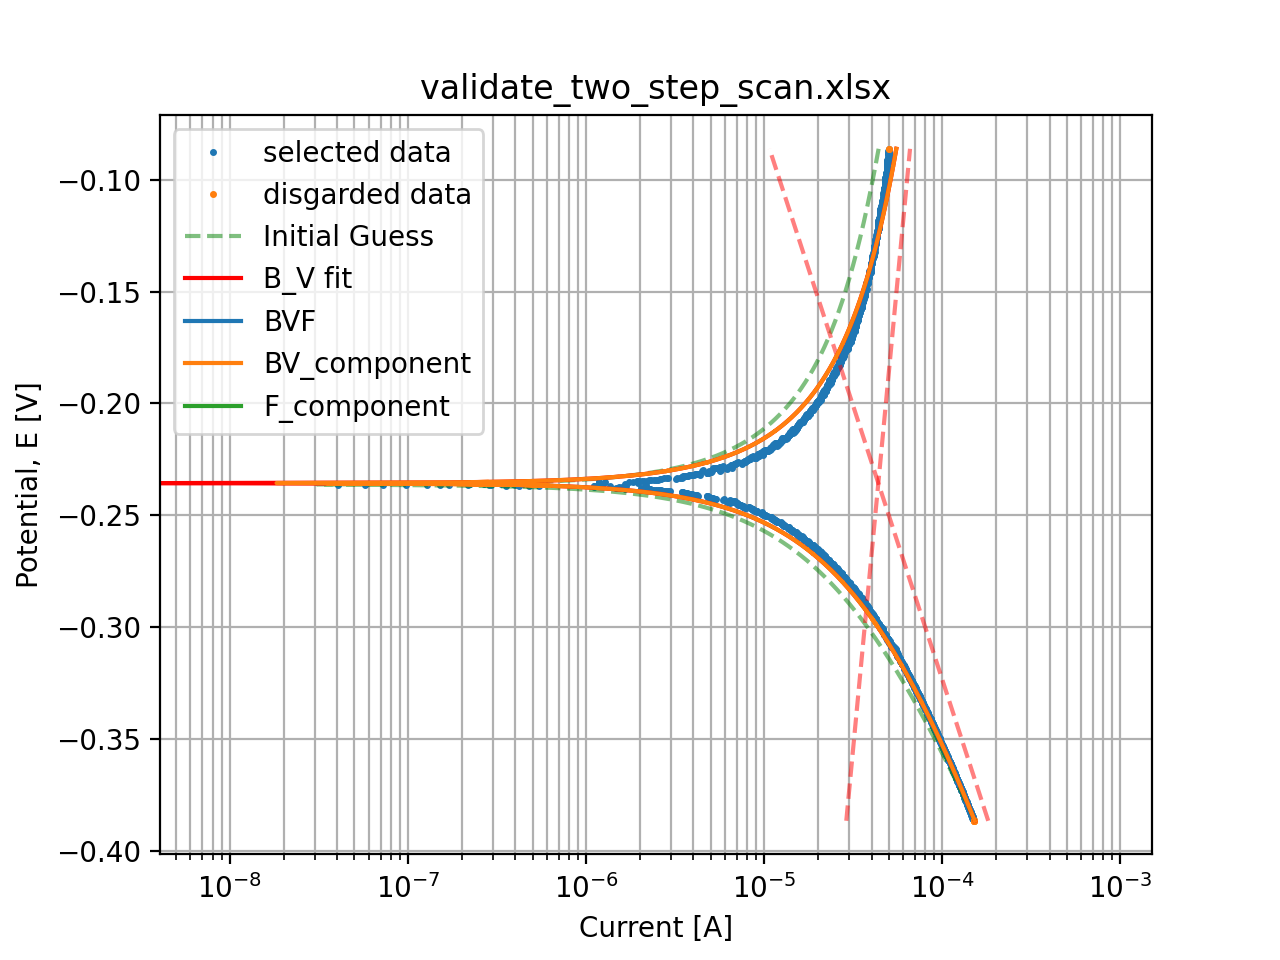

interactive(children=(IntRangeSlider(value=(5, 3019), continuous_update=False, description='data_range', layou…

In [6]:
# Two-step scan with absolute (positive) current
test2 = tf.Tafit(tf.Info('validate_two_step_scan.xlsx',area=1, scantype='two_step'))
test2.BV_LPR_interact(anodic_range=0.15,cathodic_range=0.15)


In [7]:
test2.plot_BV_F_components()

<IPython.core.display.Javascript object>


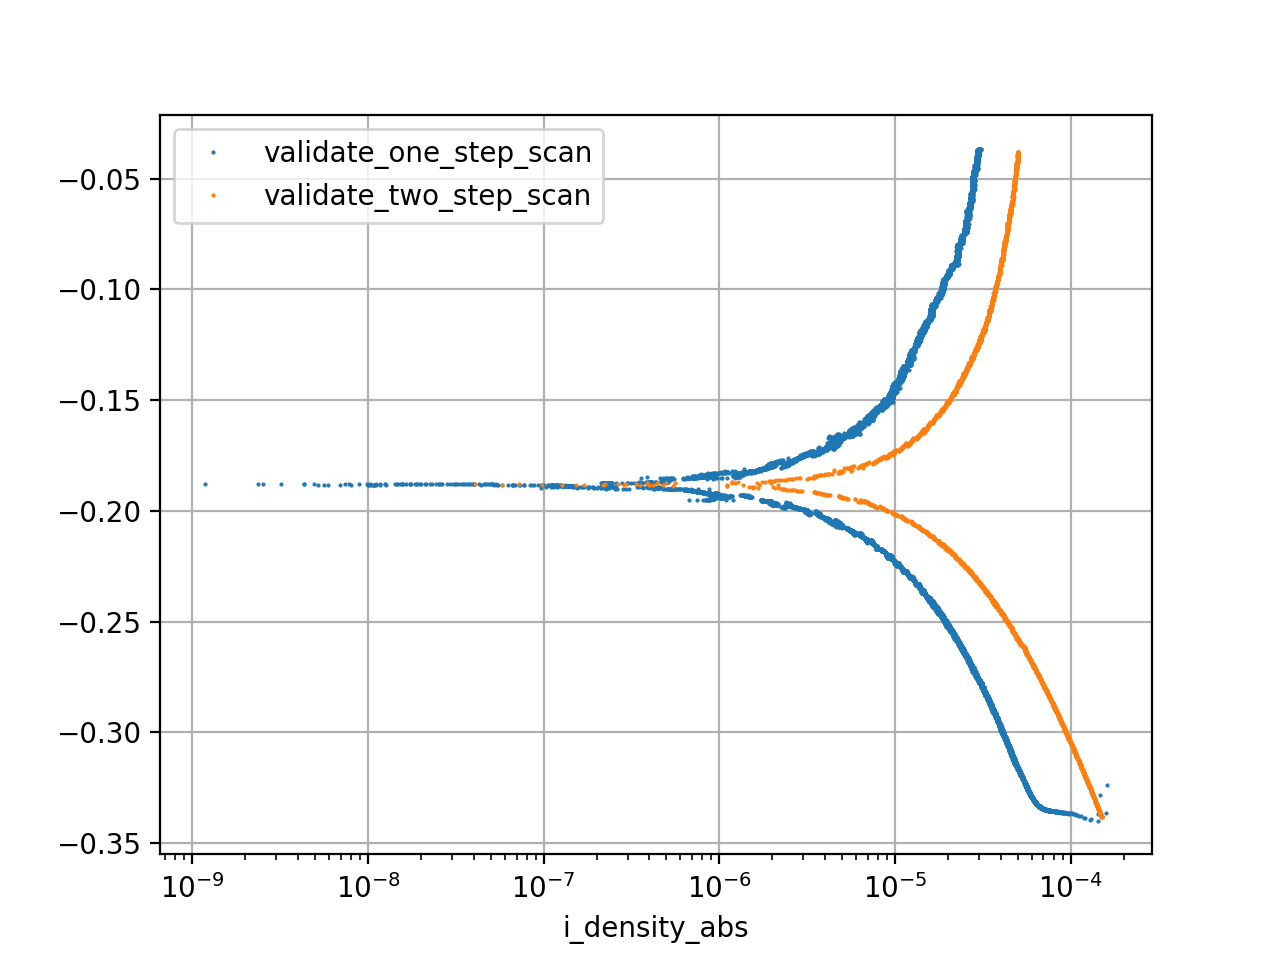

In [9]:
tf.plot_compare([test1.info,test2.info])


# Example datasets (signed current)
This example uses signed current values: positive for anodic, negative for cathodic.
These are commonly produced by well-parsed raw test data files.

# Validation with generated data
You can also pass a pandas DataFrame directly:
- first column: current
- second column: potential


In [10]:
# Ground-truth parameters
Ecorr = -0.5
Icorr = 1e-5
Ba = 0.2
Bc = -0.3
pars = (Ecorr,Icorr,Ba,Bc)


In [14]:
df=pd.DataFrame(columns=['I','E'])
E = np.linspace(Ecorr-0.2,Ecorr+0.2,2400) # OCP ±0.2 V, 1 s sampling at 0.167 mV/s
df['I'] = tf.BVeq(E=E, Eeq=Ecorr, i0=Icorr, Ba=Ba, Bc=Bc)
df['E'] = E+2e-3*np.random.randn(2400)


<IPython.core.display.Javascript object>


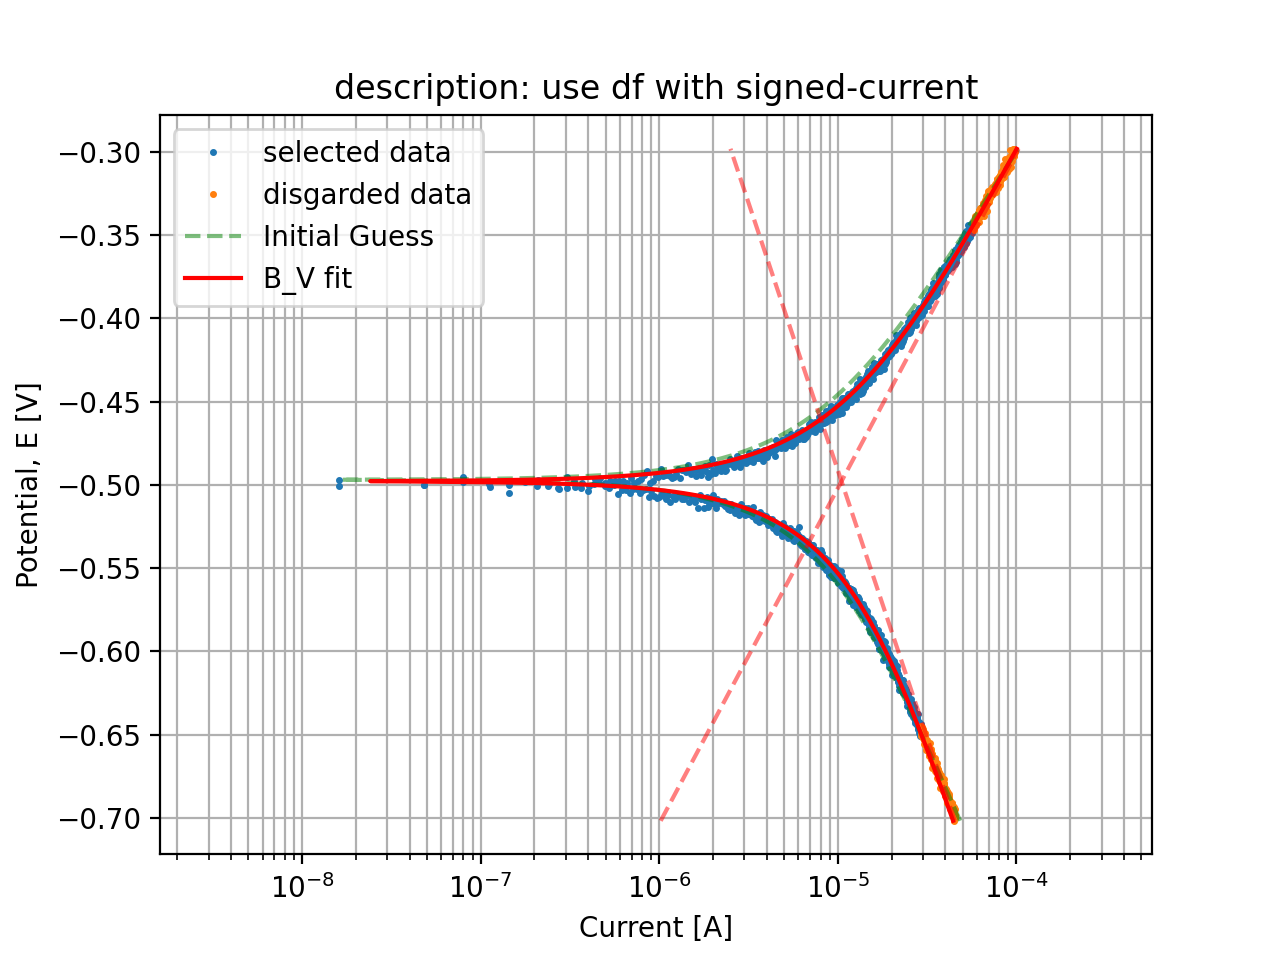

interactive(children=(IntRangeSlider(value=(316, 2138), continuous_update=False, description='data_range', lay…

In [15]:
# Use a DataFrame with signed current (common in parsed experimental data)

# Create the fit object
valid1 = tf.Tafit(
    tf.Info(
        'description: use df with signed-current', # use description string instead of filename
        pd_dfIE=df, # assign DataFrame
        use_pd_df=True, # bypass absolute-current handling
        area=1.0 # current density = current / area
        )
    )

valid1.BV_LPR_interact(anodic_range=0.15,cathodic_range=0.15)


In [16]:
print(f"expected:\n{valid1.result}")
print(f"fitted:\n{pars}")

expected:
Ecorr          -0.497832
Icorr           0.000010
Ba              0.201457
Bc             -0.321303
B               0.053765
Rp           4265.401875
Icorr_LPR       0.000013
dtype: float64
fitted:
(-0.5, 1e-05, 0.2, -0.3)


In [17]:
# Inspect all attributes on the fit object
vars(valid1)


{'info': <Tafel_LPR_fit_notebook_IRcomp_IFilm.Info at 0x168859210>,
 'area': 1.0,
 'data':              I         E  i_density  i_density_abs
 0    -0.000045 -0.699972  -0.000045       0.000045
 1    -0.000045 -0.698947  -0.000045       0.000045
 2    -0.000045 -0.699752  -0.000045       0.000045
 3    -0.000045 -0.698260  -0.000045       0.000045
 4    -0.000045 -0.698950  -0.000045       0.000045
 ...        ...       ...        ...            ...
 2395  0.000097 -0.301912   0.000097       0.000097
 2396  0.000097 -0.298064   0.000097       0.000097
 2397  0.000097 -0.299936   0.000097       0.000097
 2398  0.000098 -0.300056   0.000098       0.000098
 2399  0.000098 -0.299264   0.000098       0.000098
 
 [2400 rows x 4 columns],
 'Ecorr': -0.49783228751001596,
 'Icorr': 1.0485099381440259e-05,
 'Ba': 0.20145718382465258,
 'Bc': -0.32130309908326243,
 'B': 0.053765185786376575,
 'Rp': 4265.401875266576,
 'Icorr_LPR': 1.2604951973726133e-05,
 'fig': <Figure size 1280x960 with 1 Axes>,

In [18]:
# Display fitted results
print(valid1.result)

print()
# Individual value with full precision
print(valid1.result.Icorr)


# Icorr_LPR should be reasonably close to Icorr. Here Icorr_LPR is
# computed from a small range near OCP as if it were an LPR test.
# Strictly speaking, LPR is not valid here; we use it only as a cross-check.


Ecorr          -0.497832
Icorr           0.000010
Ba              0.201457
Bc             -0.321303
B               0.053765
Rp           4265.401875
Icorr_LPR       0.000013
dtype: float64

1.0485099381440259e-05
